### **1. Equations of Motion (Equazioni del moto)**

In [1]:
# Codifichiamo in Python le equazioni del moto relative al problema ristretto dei tre corpi:

import numpy as np

def cr3bp_equations(t, state, mu):
    """
    Equazioni del moto del problema ristretto dei tre corpi
    nel sistema sinodico (piano x–y).

    state = [x, y, vx, vy]
    mu    = parametro di massa (es. Terra–Luna)
    """
    x, y, vx, vy = state

    # Distanze dai due corpi primari
    r1 = np.sqrt((x - mu)**2 + y**2)
    r2 = np.sqrt((x + 1 - mu)**2 + y**2)

    # Accelerazioni nel sistema rotante
    ax = 2*vy + x - (1 - mu)*(x - mu)/r1**3 - mu*(x + 1 - mu)/r2**3
    ay = -2*vx + y - (1 - mu)*y/r1**3     - mu*y/r2**3

    return [vx, vy, ax, ay]
    # Questa funzione restituisce la velocità e l'accelerazione dell'oggetto all'istante t

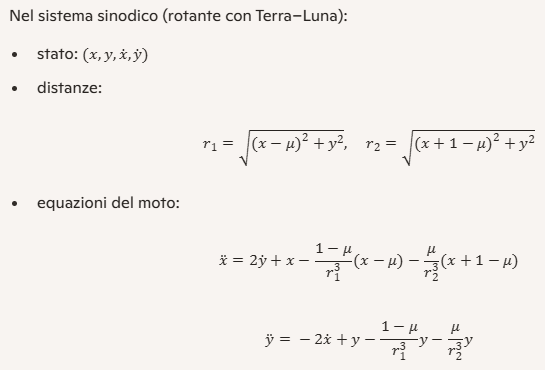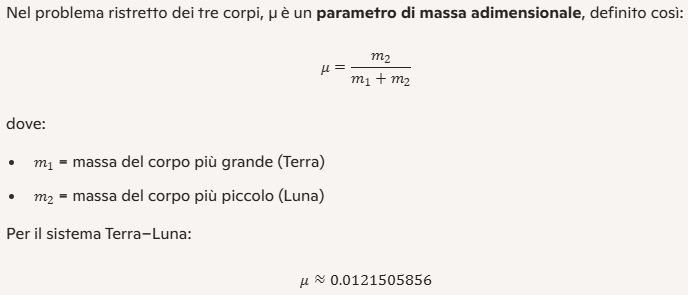

𝜇 serve per posizionare Terra e Luna nel sistema sinodico:

*   Terra → 𝑥 = −𝜇
*   Luna → 𝑥 = 1−𝜇


L’unità di distanza è la distanza Terra–Luna. Quindi:


*   Terra–Luna = 1
*   Terra ≈ –0.012
*   Luna ≈ +0.988


L’unità di tempo è scelta in modo che la velocità angolare del sistema rotante sia 1. In pratica: 𝑡 = 1 (corrisponde a circa 4.3 giorni).

### **2. Numerical Integration of the Dynamics (Integrazione numerica delle equazioni del moto)**

In [2]:
# Usiamo solve_ivp di SciPy per integrare le suddette equazioni:

from scipy.integrate import solve_ivp
# solve_ivp implementa l'algoritmo di Runge–Kutta

def integrate_trajectory(initial_state, t_final, mu, max_step=0.01):
    """
    Integra la traiettoria nel CR3BP fino a t_final.
    """
    t_span = (0.0, t_final)

    sol = solve_ivp(
        fun=lambda t, y: cr3bp_equations(t, y, mu),
        t_span=t_span,
        y0=initial_state,
        max_step=max_step,
        dense_output=False
    )

    return sol

##### L’oggetto sol restituito da solve_ivp contiene:

1.   le coordinate (x, y) dei punti che individuano la traiettoria,
2.   gli istanti in cui l'oggetto occupa quelle posizioni,
3.   le velocità che ha nei suddetti istanti.

x = sol.y[0],
y = sol.y[1],
vx = sol.y[2],
vy = sol.y[3],
t = sol.t

sol.y è una matrice 4×N:

*   riga 0 → x(t)
*   riga 1 → y(t)
*   riga 2 → vx(t)
*   riga 3 → vy(t)

sol.t contiene tutti gli istanti t di integrazione.




### **3. Trajectory Plotting (Grafico della traiettoria)**

In [3]:
# Funzione che disegna la traiettoria nel sistema sinodico dell'oggetto in movimento.

import matplotlib.pyplot as plt

def plot_trajectory(sol, mu, initial_state):
    x = sol.y[0]
    y = sol.y[1]
    t_final = sol.t[-1]

    plt.figure(figsize=(6, 6))
    plt.plot(x, y, label=f"IC={initial_state}, T={t_final:.2f}")

    # Terra e Luna
    x1, y1 = -mu, 0.0
    x2, y2 = 1 - mu, 0.0
    plt.scatter([x1], [y1], c="blue",  label="Terra")
    plt.scatter([x2], [y2], c="gray",  label="Luna")

    plt.axhline(0, color="gray", linewidth=0.3)
    plt.gca().set_aspect("equal", "box")
    plt.xlabel("x (adimensionale)")
    plt.ylabel("y (adimensionale)")
    plt.title("Traiettoria nel CR3BP Terra–Luna")
    plt.legend()
    plt.grid(True)
    plt.show()

### **4. Simulation Cases (Casi di simulazione)**

#####Proviamo ora a testare il codice con alcuni esempi di condizioni iniziali in unità adimensionali.
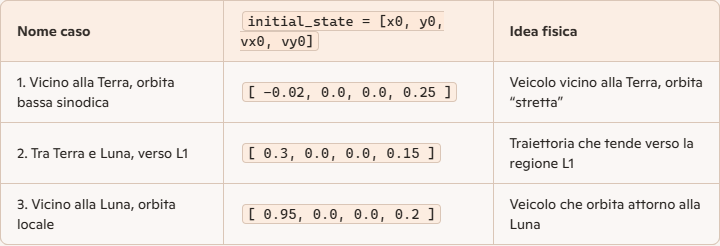

Simulazione: Vicino alla Terra


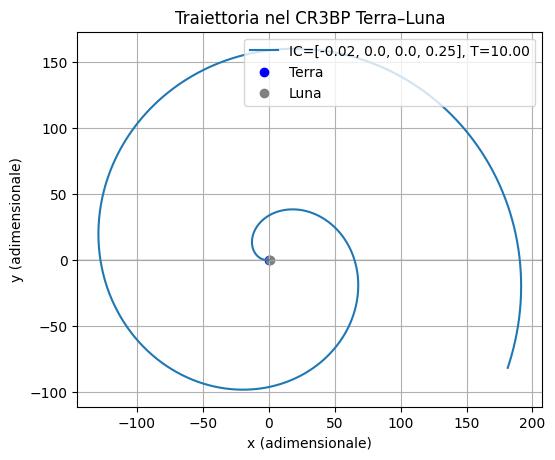

Simulazione: Verso L1


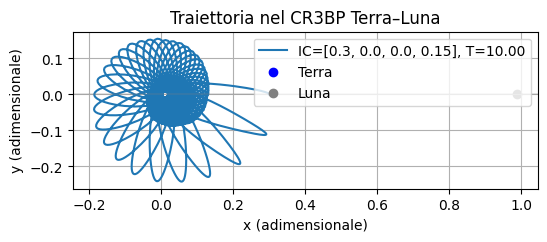

Simulazione: Vicino alla Luna


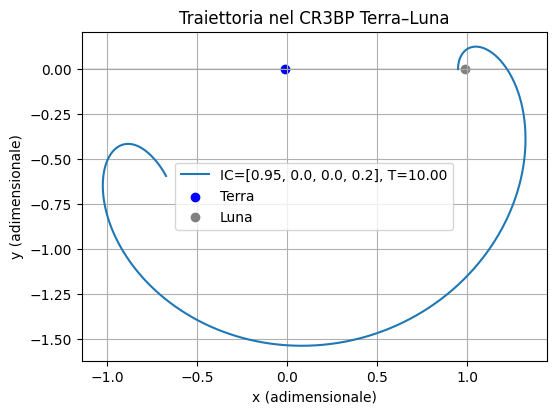

In [4]:
if __name__ == "__main__": # Serve per eseguire questo blocco solo se il file viene lanciato direttamente. Non viene eseguito se il file
    # viene importato da un altro file. In questo caso non è indispensabile.

    # Parametro di massa Terra–Luna (valore tipico)
    mu = 0.0121505856

    cases = {
        "Vicino alla Terra": [-0.02, 0.0, 0.0, 0.25],
        "Verso L1":          [0.3,   0.0, 0.0, 0.15],
        "Vicino alla Luna":  [0.95,  0.0, 0.0, 0.2]
    }

    t_final = 10.0

    for name, ic in cases.items():
        print(f"Simulazione: {name}")
        sol = integrate_trajectory(ic, t_final=t_final, mu=mu, max_step=0.01)
        plot_trajectory(sol, mu, initial_state=ic)